# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score  
from sklearn import metrics  

In [76]:
df = pd.read_csv('data/temps.csv', index_col = None)
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    object 
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 24.6+ KB


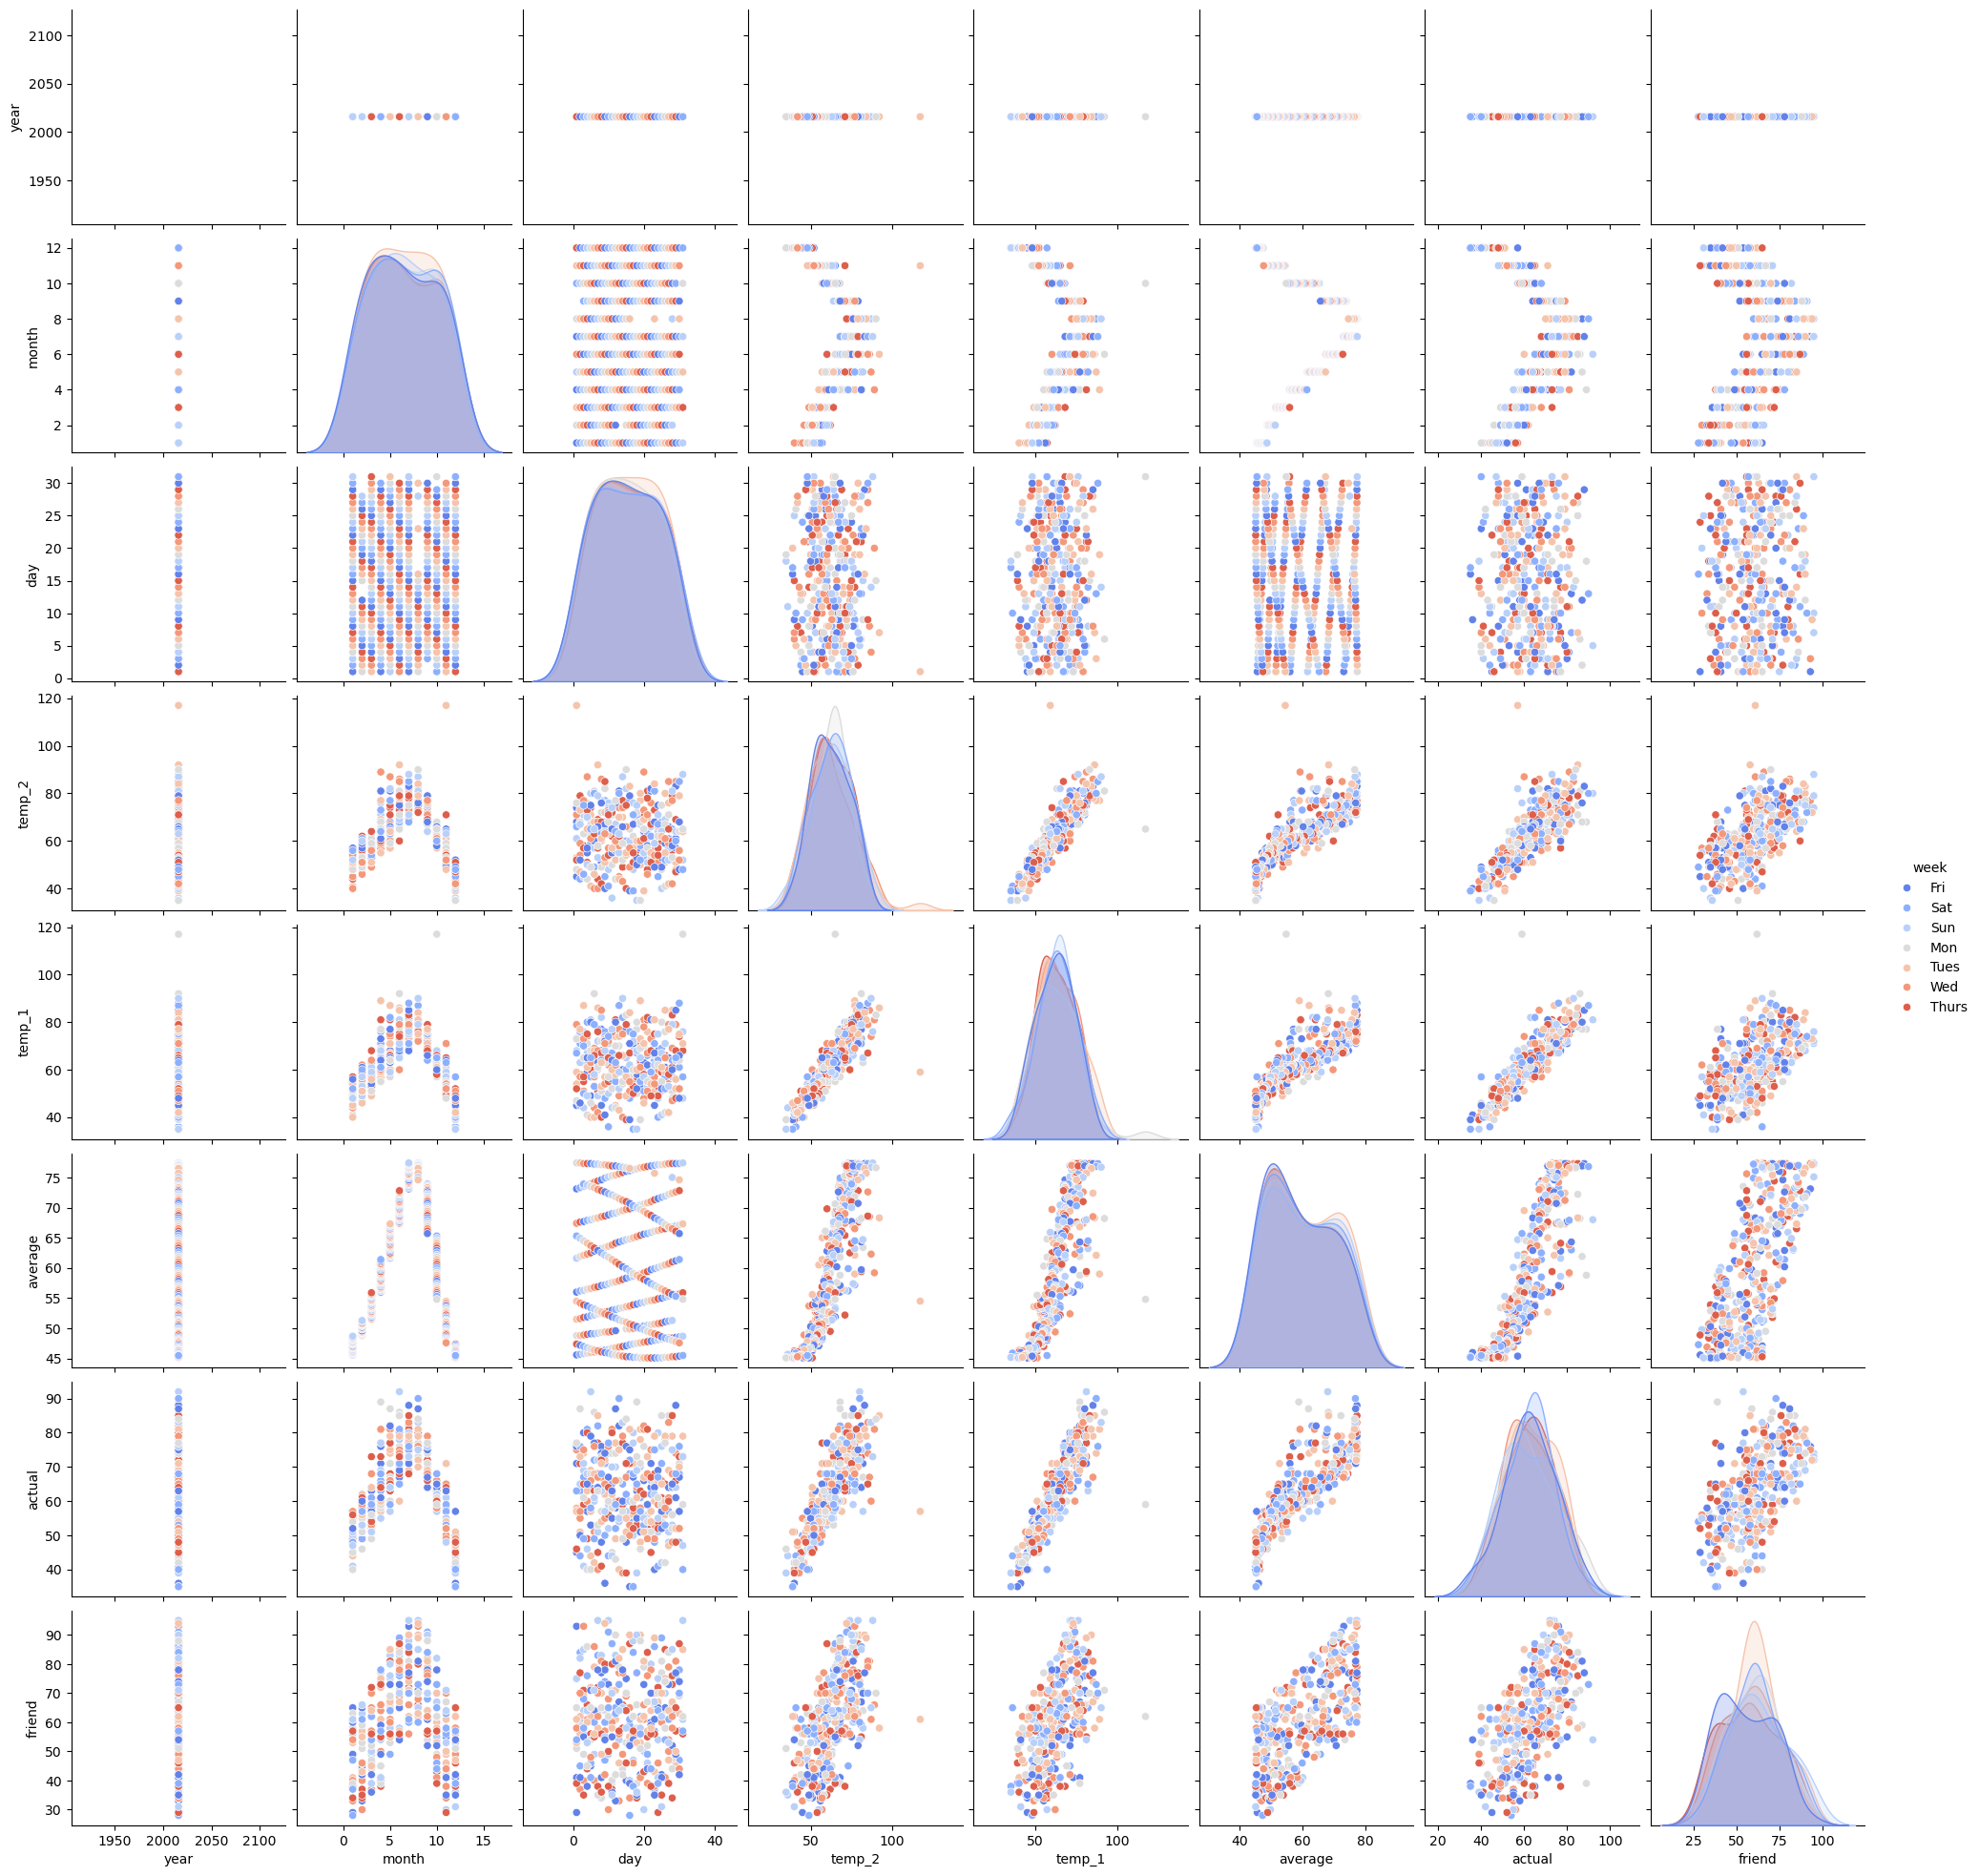

In [78]:
sns.pairplot(df, hue="week", palette = "coolwarm")


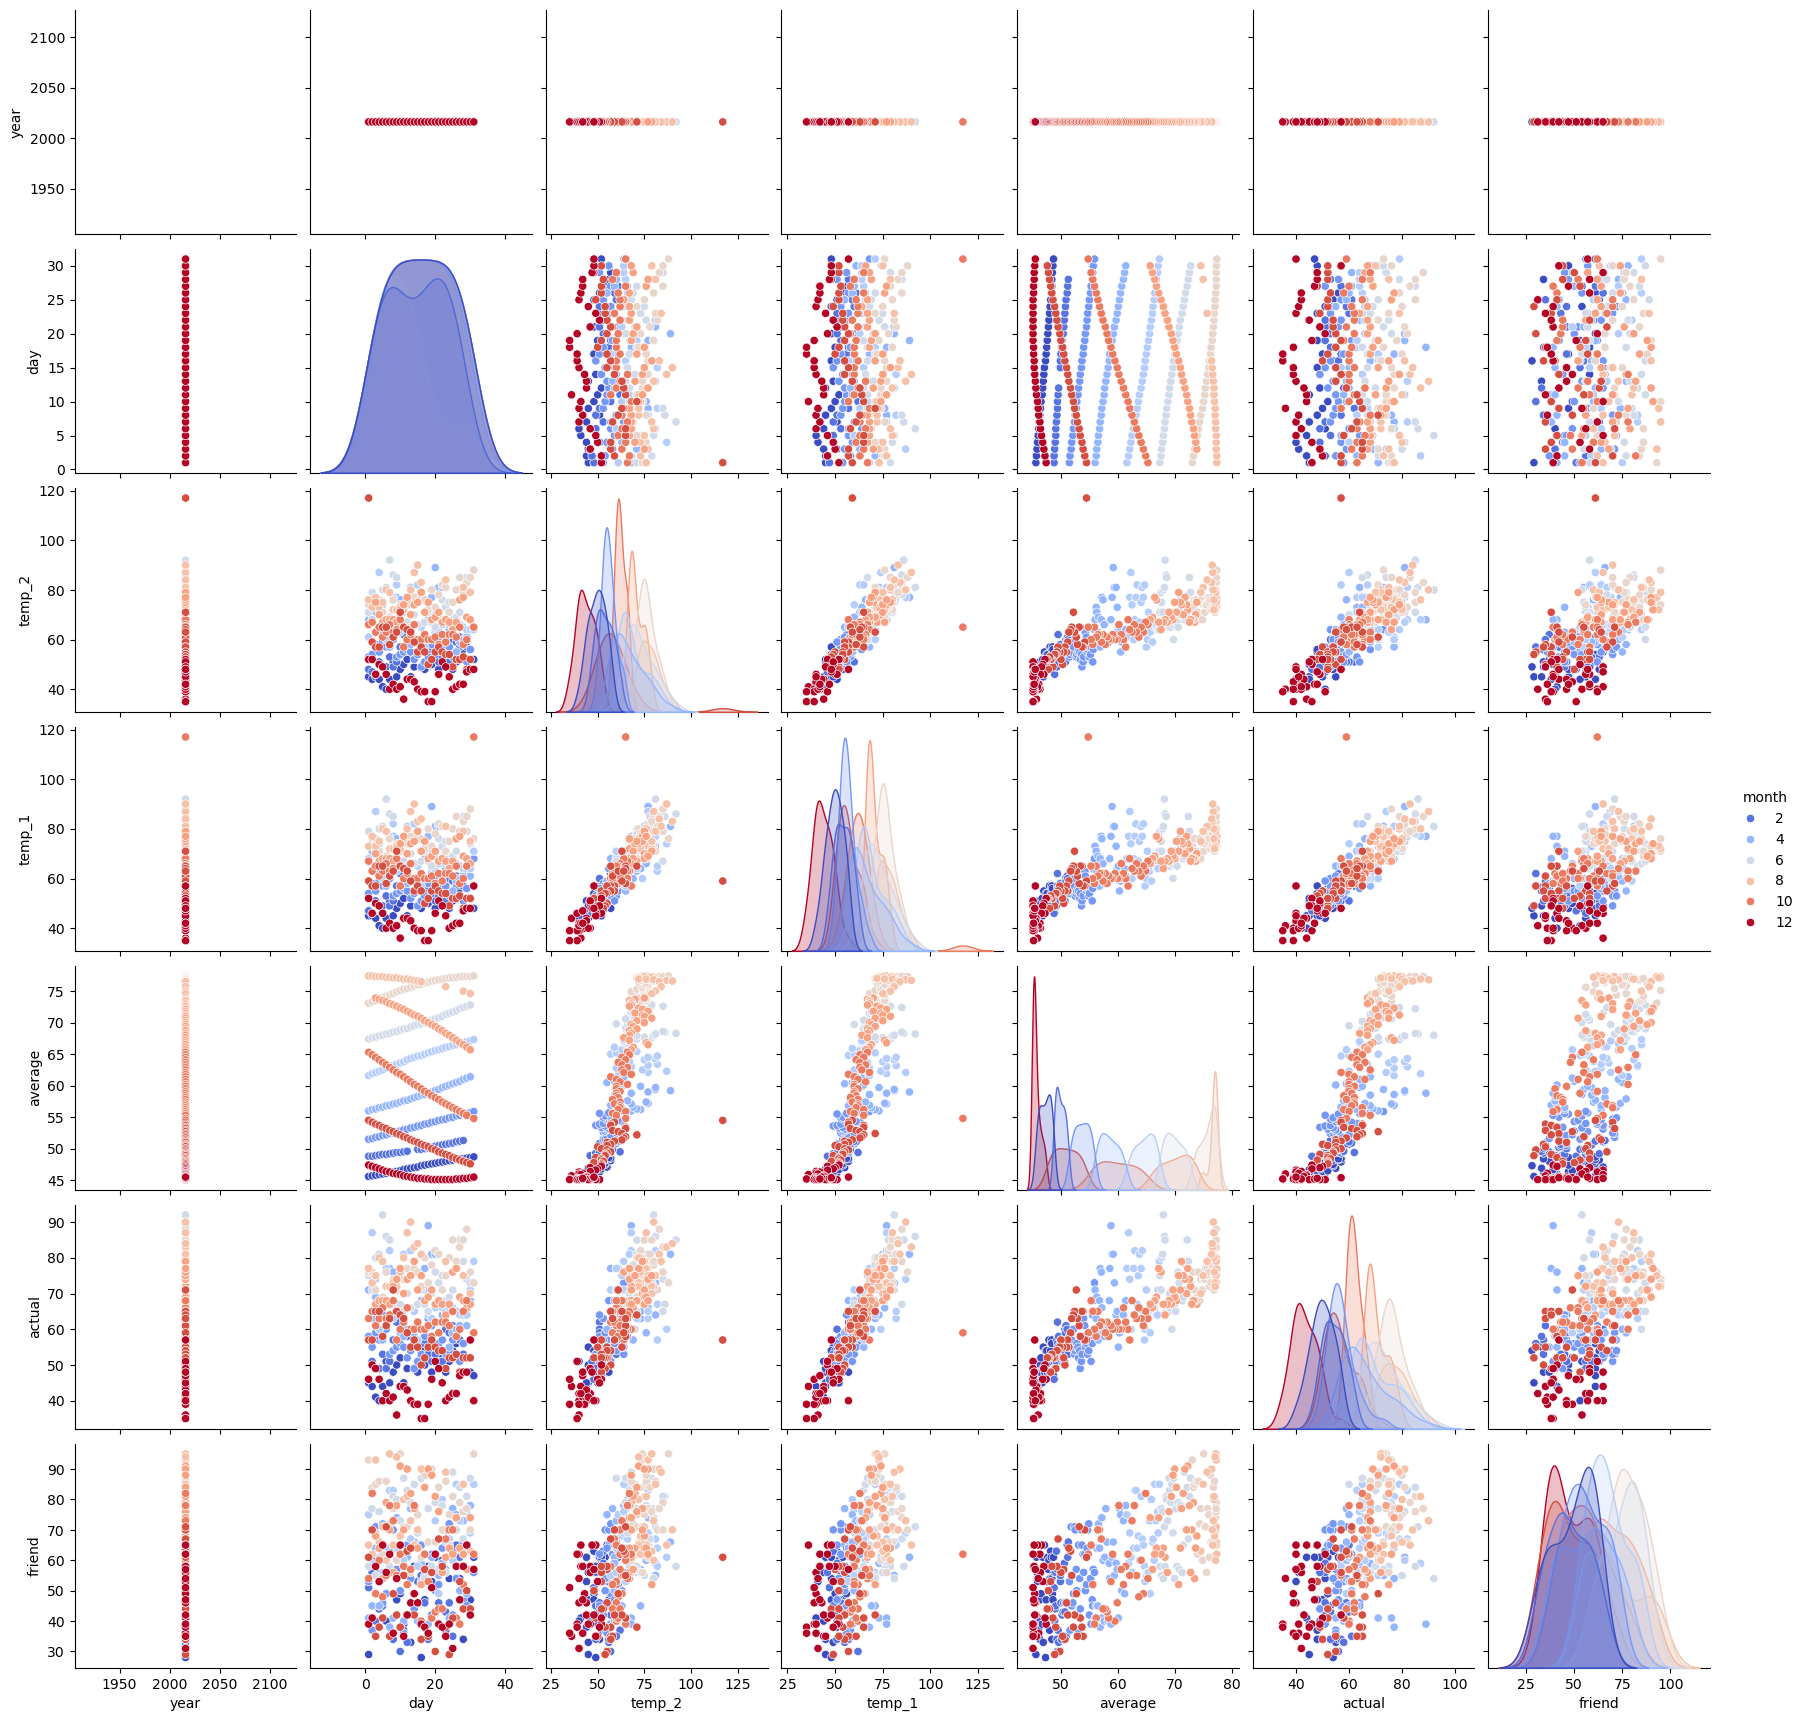

In [79]:
sns.pairplot(df, hue="month", palette = "coolwarm")

Antes de empezar a crear modelos, vamos a crear un dataframe vacio para ir metiendo las métricas de cada modelo y al final comparar todos

In [80]:
# Creamos un DataFrame vacío para ir guardando los resultados
df_comparativa = pd.DataFrame(columns=['Modelo', 'R2', 'MAE', 'MAPE', 'MSE', 'RMSE'])

# Definimos una función para no repetir código
def registrar_metricas(nombre_modelo, y_true, y_pred):
    global df_comparativa
    
    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # Creamos una nueva fila
    nueva_fila = pd.DataFrame([{
        'Modelo': nombre_modelo,
        'R2': round(r2, 4),
        'MAE': round(mae, 2),
        'MAPE': f"{round(mape, 2)}%",
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2)
    }])
    
    # La añadimos al historial
    df_comparativa = pd.concat([df_comparativa, nueva_fila], ignore_index=True)
    return df_comparativa

### 3. Selecciona variables y divide en train y test

In [81]:
# 1. Seleccionamos las columnas predictoras (Features)
features = ['temp_1', 'temp_2', 'average']
X = df[features]

# 2. Seleccionamos la variable a predecir (Target)
y = df['actual']

# Verificamos que todo esté en orden
print("Forma de X:", X.shape)
print("Primeras filas de X:")
print(X.head())

Forma de X: (348, 3)
Primeras filas de X:
   temp_1  temp_2  average
0      45      45     45.6
1      45      44     45.7
2      44      45     45.8
3      41      44     45.9
4      40      41     46.0


### 4. Entrena el modelo


In [82]:
# Dividimos los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos e instalamos el modelo
arbol = DecisionTreeRegressor(max_depth=2) # Limitamos la profundidad para evitar overfitting
arbol.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [83]:
# 1. Realizamos las predicciones para ambos sets
y_pred_train = arbol.predict(X_train)
y_pred_test = arbol.predict(X_test)

# 2. Cálculo de métricas para TRAIN
r2_train = metrics.r2_score(y_train, y_pred_train)
mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

# 3. Cálculo de métricas para TEST
r2_test = metrics.r2_score(y_test, y_pred_test)
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
mse_test = metrics.mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

# 4. Mostrar resultados por pantalla
print("--- MÉTRICAS: TRAIN ---")
print(f"R²: {r2_train:.4f} | MAE: {mae_train:.2f} | MAPE: {mape_train:.2f}% | RMSE: {rmse_train:.2f}")

print("\n--- MÉTRICAS: TEST ---")
print(f"R²: {r2_test:.4f} | MAE: {mae_test:.2f} | MAPE: {mape_test:.2f}% | RMSE: {rmse_test:.2f}")

# 5. Registrar en el dataframe comparativo (usando la función que creamos)
# Registramos ambas para poder compararlas después en la tabla final
registrar_metricas("Árbol Inicial (Train)", y_train, y_pred_train)
registrar_metricas("Árbol Inicial (Test)", y_test, y_pred_test)

--- MÉTRICAS: TRAIN ---
R²: 0.7929 | MAE: 4.19 | MAPE: 6.82% | RMSE: 5.35

--- MÉTRICAS: TEST ---
R²: 0.7308 | MAE: 4.89 | MAPE: 7.74% | RMSE: 6.14


/var/folders/2k/yg7q69cj067fsvsj5dgzgt7m0000gn/T/ipykernel_41003/287141854.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparativa = pd.concat([df_comparativa, nueva_fila], ignore_index=True)


,Modelo,R2,MAE,MAPE,MSE,RMSE
0,Árbol Inicial (Train),0.7929,4.19,6.82%,28.62,5.35
1,Árbol Inicial (Test),0.7308,4.89,7.74%,37.65,6.14


### 6. Representa el árbol de decisión

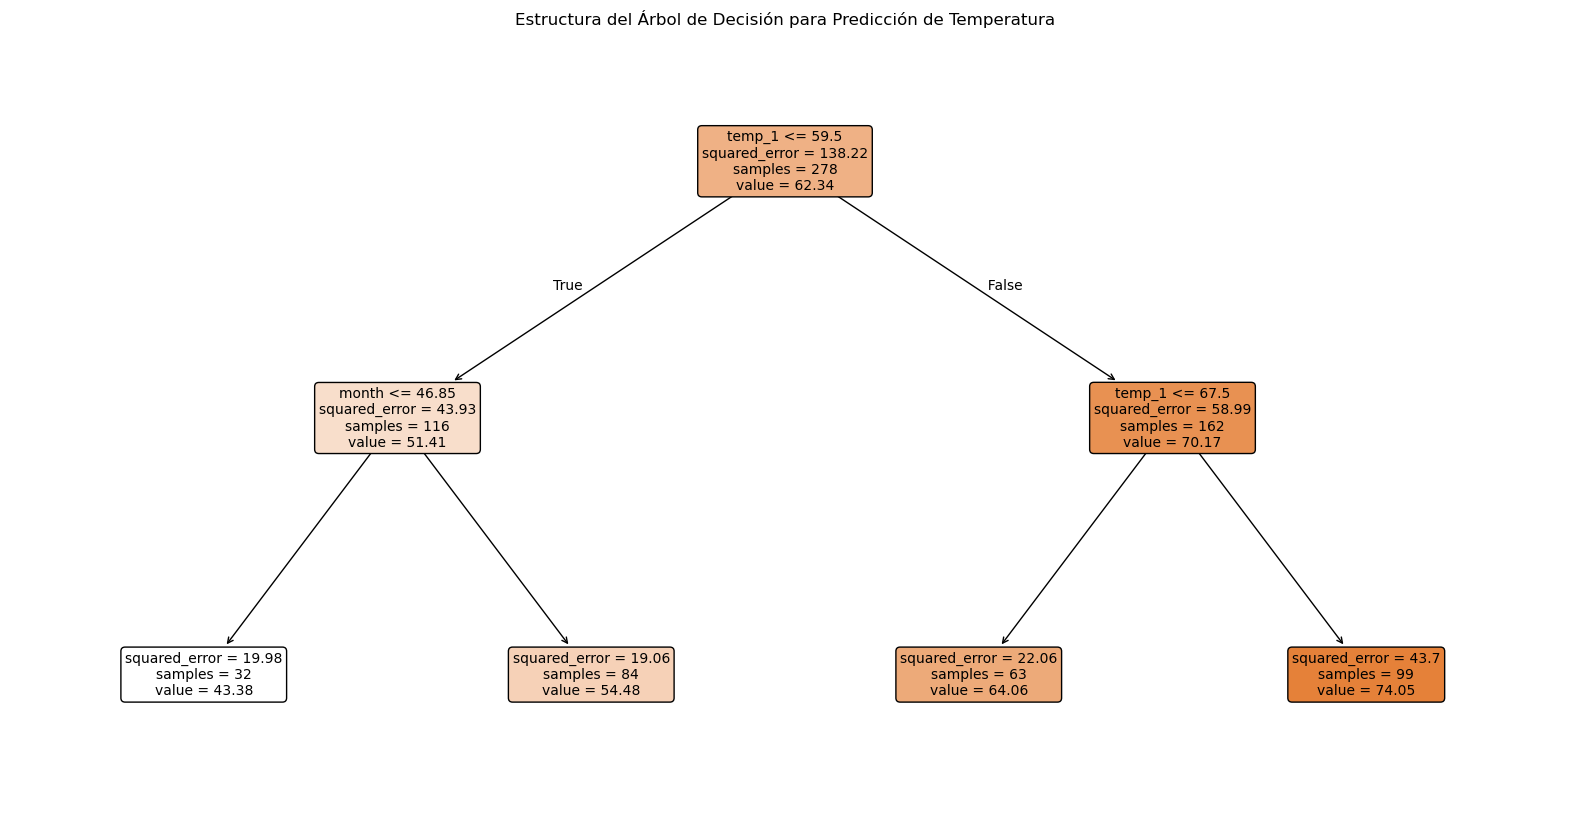

In [84]:
# Configuramos el tamaño de la figura para que sea legible
plt.figure(figsize=(20, 10))

# Dibujamos el árbol
plot_tree(
    arbol, 
    feature_names=['temp_1', 'temp_2', 'month'], # Nombres de tus variables
    filled=True,              # Colorea los nodos según el valor
    rounded=True,             # Bordes redondeados para estética
    fontsize=10,              # Tamaño de letra
    precision=2               # Decimales a mostrar
)

plt.title("Estructura del Árbol de Decisión para Predicción de Temperatura")
plt.show()

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [85]:
# 1. Definir y entrenar el nuevo modelo con profundidad 3
arbol_v2 = DecisionTreeRegressor(max_depth=3, random_state=42)
arbol_v2.fit(X_train, y_train)



,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [86]:
# 1. Realizamos las predicciones para ambos sets con el modelo v2 (depth=3)
y_pred_v2_train = arbol_v2.predict(X_train)
y_pred_v2_test = arbol_v2.predict(X_test)

# 2. Cálculo de métricas para TRAIN (v2)
r2_v2_train = metrics.r2_score(y_train, y_pred_v2_train)
mae_v2_train = metrics.mean_absolute_error(y_train, y_pred_v2_train)
mse_v2_train = metrics.mean_squared_error(y_train, y_pred_v2_train)
rmse_v2_train = np.sqrt(mse_v2_train)
mape_v2_train = np.mean(np.abs((y_train - y_pred_v2_train) / y_train)) * 100

# 3. Cálculo de métricas para TEST (v2)
r2_v2_test = metrics.r2_score(y_test, y_pred_v2_test)
mae_v2_test = metrics.mean_absolute_error(y_test, y_pred_v2_test)
mse_v2_test = metrics.mean_squared_error(y_test, y_pred_v2_test)
rmse_v2_test = np.sqrt(mse_v2_test)
mape_v2_test = np.mean(np.abs((y_test - y_pred_v2_test) / y_test)) * 100

# 4. Mostrar resultados por pantalla
print("--- MÉTRICAS ÁRBOL V2 (DEPTH=3): TRAIN ---")
print(f"R²: {r2_v2_train:.4f} | MAE: {mae_v2_train:.2f} | MAPE: {mape_v2_train:.2f}% | RMSE: {rmse_v2_train:.2f}")

print("\n--- MÉTRICAS ÁRBOL V2 (DEPTH=3): TEST ---")
print(f"R²: {r2_v2_test:.4f} | MAE: {mae_v2_test:.2f} | MAPE: {mape_v2_test:.2f}% | RMSE: {rmse_v2_test:.2f}")

# 5. Registrar en el dataframe comparativo
registrar_metricas("Árbol Profundidad 3 (Train)", y_train, y_pred_v2_train)
registrar_metricas("Árbol Profundidad 3 (Test)", y_test, y_pred_v2_test)

--- MÉTRICAS ÁRBOL V2 (DEPTH=3): TRAIN ---
R²: 0.8397 | MAE: 3.68 | MAPE: 5.87% | RMSE: 4.71

--- MÉTRICAS ÁRBOL V2 (DEPTH=3): TEST ---
R²: 0.7787 | MAE: 4.27 | MAPE: 6.74% | RMSE: 5.56


,Modelo,R2,MAE,MAPE,MSE,RMSE
0,Árbol Inicial (Train),0.7929,4.19,6.82%,28.62,5.35
1,Árbol Inicial (Test),0.7308,4.89,7.74%,37.65,6.14
2,Árbol Profundidad 3 (Train),0.8397,3.68,5.87%,22.15,4.71
3,Árbol Profundidad 3 (Test),0.7787,4.27,6.74%,30.95,5.56


### 9. Vuelve a representar su árbol

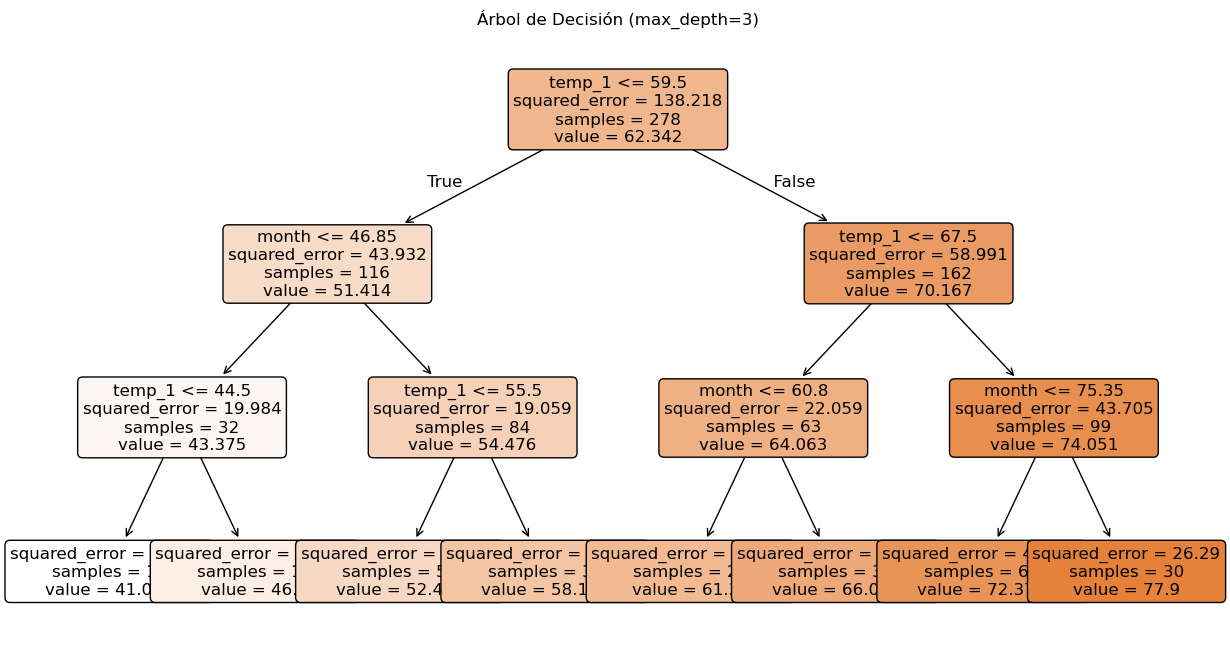

In [87]:
# 2. Representación visual del nuevo árbol
plt.figure(figsize=(15, 8))
plot_tree(
    arbol_v2, 
    feature_names=['temp_1', 'temp_2', 'month'], 
    filled=True, 
    rounded=True, 
    fontsize=12
)

plt.title("Árbol de Decisión (max_depth=3)")
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# 1. Definimos el modelo base
modelo_base = DecisionTreeRegressor(random_state=42)

# 2. Rejilla de parámetros corregida
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'] 
}

# 3. Configuración del GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5, 
    scoring='r2', 
    n_jobs=-1
)

# 4. Entrenamiento (Búsqueda de los mejores parámetros)
grid_search.fit(X_train, y_train)

# 5. Extraer el mejor modelo resultante
mejor_modelo = grid_search.best_estimator_

# 6. Realizar predicciones para ambos conjuntos
y_pred_grid_train = mejor_modelo.predict(X_train)
y_pred_grid_test = mejor_modelo.predict(X_test)

# 7. Cálculo de métricas para TRAIN (Optimizado)
r2_grid_train = metrics.r2_score(y_train, y_pred_grid_train)
mae_grid_train = metrics.mean_absolute_error(y_train, y_pred_grid_train)
mse_grid_train = metrics.mean_squared_error(y_train, y_pred_grid_train)
rmse_grid_train = np.sqrt(mse_grid_train)
mape_grid_train = np.mean(np.abs((y_train - y_pred_grid_train) / y_train)) * 100

# 8. Cálculo de métricas para TEST (Optimizado)
r2_grid_test = metrics.r2_score(y_test, y_pred_grid_test)
mae_grid_test = metrics.mean_absolute_error(y_test, y_pred_grid_test)
mse_grid_test = metrics.mean_squared_error(y_test, y_pred_grid_test)
rmse_grid_test = np.sqrt(mse_test)
mape_grid_test = np.mean(np.abs((y_test - y_pred_grid_test) / y_test)) * 100

# 9. Mostrar resultados y parámetros
print("--- MEJORES PARÁMETROS ENCONTRADOS ---")
print(grid_search.best_params_)

print("\n--- MÉTRICAS MODELO OPTIMIZADO: TRAIN ---")
print(f"R²: {r2_grid_train:.4f} | MAE: {mae_grid_train:.2f} | MAPE: {mape_grid_train:.2f}% | RMSE: {rmse_grid_train:.2f}")

print("\n--- MÉTRICAS MODELO OPTIMIZADO: TEST ---")
print(f"R²: {r2_grid_test:.4f} | MAE: {mae_grid_test:.2f} | MAPE: {mape_grid_test:.2f}% | RMSE: {rmse_grid_test:.2f}")

# 10. Registrar en el dataframe comparativo
registrar_metricas("Árbol Optimizado (Train)", y_train, y_pred_grid_train)
registrar_metricas("Árbol Optimizado (Test)", y_test, y_pred_grid_test)

--- MEJORES PARÁMETROS ENCONTRADOS ---
{'criterion': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 2}

--- MÉTRICAS MODELO OPTIMIZADO: TRAIN ---
R²: 0.8610 | MAE: 3.36 | MAPE: 5.36% | RMSE: 4.38

--- MÉTRICAS MODELO OPTIMIZADO: TEST ---
R²: 0.8020 | MAE: 4.00 | MAPE: 6.39% | RMSE: 6.14


,Modelo,R2,MAE,MAPE,MSE,RMSE
0,Árbol Inicial (Train),0.7929,4.19,6.82%,28.62,5.35
1,Árbol Inicial (Test),0.7308,4.89,7.74%,37.65,6.14
2,Árbol Profundidad 3 (Train),0.8397,3.68,5.87%,22.15,4.71
3,Árbol Profundidad 3 (Test),0.7787,4.27,6.74%,30.95,5.56
4,Árbol Optimizado (Train),0.8610,3.36,5.36%,19.21,4.38
5,Árbol Optimizado (Test),0.8020,4.00,6.39%,27.68,5.26


HACEMOS UN CROSS VALIDATION DEL ULTIMO MODELO PARA VALIDAR LOS DIFERENTES FOLDS

In [94]:
from sklearn.model_selection import cross_val_score, cross_validate

# 11. Validación Cruzada del Modelo Optimizado
print("\n--- VALIDACIÓN CRUZADA (K-FOLD) DEL MEJOR MODELO ---")

# Obtenemos los scores de R2 para cada fold (usando 5 folds por defecto)
cv_scores = cross_val_score(mejor_modelo, X_train, y_train, cv=5, scoring='r2')

# Si quieres ver múltiples métricas a la vez (R2 y MAE por ejemplo):
scoring_mult = ['r2', 'neg_mean_absolute_error']
cv_results = cross_validate(mejor_modelo, X_train, y_train, cv=5, scoring=scoring_mult)

# Mostramos los resultados de cada fold
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print("-" * 30)
print(f"Promedio R²: {cv_scores.mean():.4f}")
print(f"Desviación Estándar: {cv_scores.std():.4f}")

# Nota: El MAE en cross_validate viene como negativo por convención de scikit-learn
mae_cv = -cv_results['test_neg_mean_absolute_error']
print(f"Promedio MAE: {mae_cv.mean():.2f}")


--- VALIDACIÓN CRUZADA (K-FOLD) DEL MEJOR MODELO ---
Fold 1: R² = 0.8194
Fold 2: R² = 0.8071
Fold 3: R² = 0.7497
Fold 4: R² = 0.7883
Fold 5: R² = 0.8123
------------------------------
Promedio R²: 0.7954
Desviación Estándar: 0.0251
Promedio MAE: 4.10


### 11. Obten el `feature_importances` de cada variable en el último modelo

Importancia de las variables:
   Feature  Importancia
0   temp_1     0.868013
2  average     0.131987
1   temp_2     0.000000


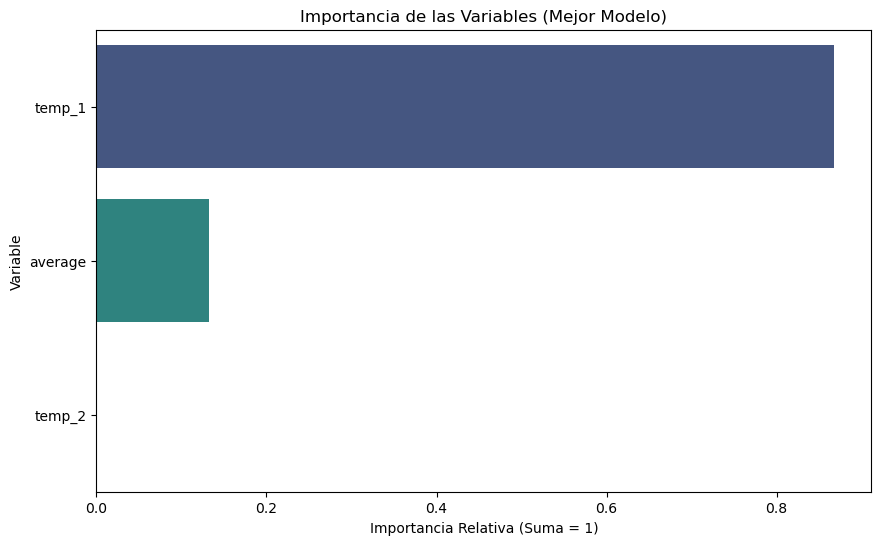

In [90]:


# 1. Extraer las importancias del mejor modelo del Grid Search
importancias = mejor_modelo.feature_importances_
nombres_features = X.columns

# 2. Crear un DataFrame para facilitar la visualización
df_importancia = pd.DataFrame({
    'Feature': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Mostrar los valores numéricos
print("Importancia de las variables:")
print(df_importancia)

# 4. Crear un gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis', hue='Feature', legend=False)
plt.title('Importancia de las Variables (Mejor Modelo)')
plt.xlabel('Importancia Relativa (Suma = 1)')
plt.ylabel('Variable')
plt.show()

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [ ]:
temps.head()

In [99]:
# Convertimos el problema a clasificación
# 1 si es > 59, 0 si es <= 59
df['es_caluroso'] = (df['actual'] > 59).astype(int)

# Definimos nuestras X e y de nuevo
X_clas = df[['temp_1', 'average']]
y_clas = df['es_caluroso']

# Dividimos en entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clas, y_clas, test_size=0.2, random_state=42)

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Modelo base
clf_base = DecisionTreeClassifier(random_state=42)

# 2. Rejilla de parámetros
param_grid_clf = {
    'max_depth': [2, 3, 4, 5, 6],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 5]
}

# 3. Grid Search
grid_clf = GridSearchCV(clf_base, param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_clf.fit(X_train_c, y_train_c)

# 4. Mejor modelo
mejor_clf = grid_clf.best_estimator_
y_pred_clf = mejor_clf.predict(X_test_c)

In [101]:
print("Mejores parámetros:", grid_clf.best_params_)
print(f"\nAccuracy (Exactitud): {accuracy_score(y_test_c, y_pred_clf):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_c, y_pred_clf))
print("\nInforme de Clasificación:")
print(classification_report(y_test_c, y_pred_clf))

# Registrar en tu tabla comparativa (opcional, adaptando la función)
# registrar_metricas("Árbol Clasificación (Test)", y_test_c, y_pred_clf)

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2}

Accuracy (Exactitud): 0.8714

Matriz de Confusión:
[[20  8]
 [ 1 41]]

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.95      0.71      0.82        28
           1       0.84      0.98      0.90        42

    accuracy                           0.87        70
   macro avg       0.89      0.85      0.86        70
weighted avg       0.88      0.87      0.87        70



/opt/homebrew/Caskroom/miniforge/base/envs/bootcamp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


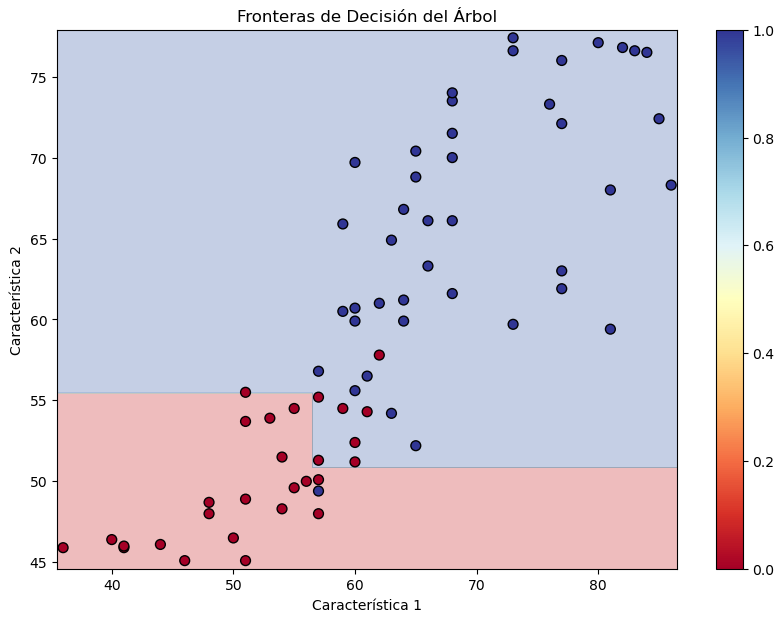

In [102]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundaries(X, y, model, title="Fronteras de Decisión del Árbol"):
    # Si X tiene más de 2 columnas, seleccionamos las dos primeras para el plot
    if X.shape[1] > 2:
        print("Aviso: El dataset tiene más de 2 dimensiones. Solo se graficarán las dos primeras.")
        X_plot = X[:, :2]
        # Re-entrenamos ligeramente solo para el plot o asegúrate de pasar un modelo ya entrenado con 2 vars
        model.fit(X_plot, y)
    else:
        X_plot = X

    # Definir los límites del gráfico
    x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    
    # Crear la malla (mesh grid)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predecir sobre la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Configurar el gráfico
    plt.figure(figsize=(10, 7))
    
    # Dibujar las fronteras de decisión (los "cortes")
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Dibujar las muestras (la dispersión)
    scatter = plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, 
                         edgecolors='k', marker='o', s=50, cmap=plt.cm.RdYlBu)
    
    plt.title(title)
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.colorbar(scatter)
    plt.show()

# Ejecutar la función con tus datos de TEST o TRAIN
# Nota: Convertimos a numpy array (.values) si son DataFrames de Pandas
plot_decision_boundaries(X_test_c.values if hasattr(X_test_c, 'values') else X_test_c, 
                         y_test_c, 
                         mejor_clf)